# 周杰伦歌词生成

In [ ]:
# # 从jupyter服务器下载数据集
# import os
# from IPython.display import FileLink, display

# file_path = 'data/jaychou_lyrics.txt.zip'

# if os.path.exists(file_path):
#     display(FileLink(file_path, result_html_prefix="点击下载: "))
# else:
#     print(f"错误：文件不存在于路径 {file_path}，请检查路径或先运行生成文件的代码。")

## 1、读取数据集

In [1]:
import tensorflow as tf
from tensorflow import keras
import random
import zipfile
import numpy as np
import math
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM, SimpleRNN

In [2]:
with zipfile.ZipFile('data/jaychou_lyrics.txt.zip') as zin:
    with zin.open('jaychou_lyrics.txt') as f:
        corpus_chars = f.read().decode('utf-8')

In [3]:
print(corpus_chars[:40])

想要有直升机
想要和你飞到宇宙去
想要和你融化在一起
融化在宇宙里
我每天每天每


## 2、建立字符索引

In [4]:
# 使用set()函数将数据集中重复的字符删掉，然后将其放入列表
idx_to_char = list(set(corpus_chars))
len(idx_to_char)

2583

In [5]:
# 将字符映射到索引
char_to_idx = {char: i for i, char in enumerate(idx_to_char)}

In [6]:
vocab_size = len(char_to_idx)
vocab_size

2583

In [7]:
# 将字符转化为索引
corpus_indices = [char_to_idx[char] for char in corpus_chars]
len(corpus_indices)

63282

corpus_indices中是原始数据集corpus_char中所有字符的索引值。我们可以打印前20个字符机器对应的索引：

In [8]:
sample = corpus_indices[1000:1020]
print('indices:', sample)
print('chars:', ''.join([idx_to_char[idx] for idx in sample]))

indices: [2096, 680, 544, 268, 1845, 1816, 2096, 305, 1214, 305, 1214, 1765, 830, 1363, 2203, 2096, 1718, 1845, 2435, 105]
chars: 
随风跟著我
一口一口吃掉忧愁
载著你 


## 3、时序数据采样

与其他实验数据不同的是，时序数据的一个样本通常包含连续的字符。假设时间步数为5，样本序列为5个字符，即“想”“要”“有”“直”“升”。该样本的标签序列为这些字符分别在训练集中的下一个字符，即“要”“有”“直”“升”“机”。我们有两种方式对时序数据进行采样，分别是随机采样和相邻采样。设批量大小batch_size指每个小批量的样本数，num steps为每个样本所包含的时间步数：


### 3.1随机采样

在随机采样中，每个样本是原始序列上任意截取的一段序列。相邻的两个随机小批量在原始序列上的位置不一定相邻。因此，我们无法用一个小批量最终时间步的隐藏状态来初始化下一个小批量的隐藏状态。在训练模型时，每次随机采样前都需要重新初始化隐藏状态。


### 3.2相邻采样

除对原始序列做随机采样之外，我们还可以令相邻的两个随机小批量在原始序列上的位置相邻。这时候，我们就可以用一个小批量最终时间步的隐藏状态来初始化下一个小批量的隐藏状态，从而使下一个小批量的输出也取决于当前小批量的输入，并如此循环下去。这对实现循环神经网络造成了两方面影响：一方面，在训练模型时，我们只需在每一个迭代周期开始时初始化隐藏状态；另一方面，当多个相邻小批量通过传递隐藏状态串联起来时，模型参数的梯度计算将依赖所有串联起来的小批量序列。同一迭代周期中，随着迭代次数的增加，梯度的计算开销会越来越大。为了使模型参数的梯度计算只依赖一次迭代读取的小批量序列，我们可以在每次读取小批量前将隐藏状态从计算图中分离出来。


In [9]:
def data_iter_consecutive(corpus_indices, batch_size, num_steps, ctx=None):
    corpus_indices = np.array(corpus_indices)
    data_len = len(corpus_indices)
    batch_len = data_len // batch_size
    # 去掉尾部零头
    indices = corpus_indices[0: batch_size*batch_len].reshape((batch_size, batch_len))
    epoch_size = (batch_len - 1) // num_steps
    
    for i in range(epoch_size):
        i = i * num_steps
        X = indices[:, i: i+num_steps]
        Y = indices[:, i+1: i+num_steps+1]
        yield X, Y

In [10]:
# 用法示例
my_seq = list(range(30))
for  X, Y in data_iter_consecutive(my_seq, batch_size=2, num_steps=6):
    print('X:', X, '\nY:', Y, '\n')

X: [[ 0  1  2  3  4  5]
 [15 16 17 18 19 20]] 
Y: [[ 1  2  3  4  5  6]
 [16 17 18 19 20 21]] 

X: [[ 6  7  8  9 10 11]
 [21 22 23 24 25 26]] 
Y: [[ 7  8  9 10 11 12]
 [22 23 24 25 26 27]] 



## 4、定义模型

### 4.1 定义循环神经网络层

Keras的Rnn模块提供了循环神经网络的实现。下面构造一个含单隐藏层、隐藏单元个数为256的循环神经网络层mnn layer，并对权重做初始化。mnn layer的输入形状为(批量大小，时间步数，词典大小)，在前向计算后会分别返回输出和隐藏状态。
返回的隐藏状态指的是隐藏层在最后时间步的隐藏状态：当隐藏层有多层时，每一层的隐藏状态都会记录在该变量中。

In [11]:
num_hiddens = 256
batch_size = 160
num_steps = 35

model = Sequential()

model.add(keras.Input(batch_input_shape=(batch_size, num_steps)))
model.add(Embedding(output_dim=256,
                    input_dim=vocab_size,
                    input_length=num_steps))
model.add(LSTM(units=num_hiddens,
               return_sequences=True,
               stateful=True))
model.add(Dense(units=vocab_size, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (160, 35, 256)            661248    
                                                                 
 lstm (LSTM)                 (160, 35, 256)            525312    
                                                                 
 dense (Dense)               (160, 35, 2583)           663831    
                                                                 
Total params: 1,850,391
Trainable params: 1,850,391
Non-trainable params: 0
_________________________________________________________________


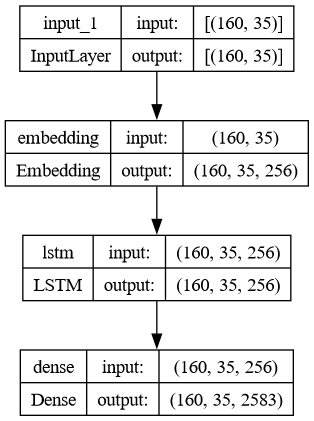

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True, show_layer_names=True)

将经过采样后的样本直接输入此网络中时，它经过的处理操作依次为：输入形状为(批量大小，时间步数)利用embedding编码得到(批量大小，时间步数，embedding大小)输入到NN层，得到(批量大小，时间步数，隐藏单元个数)经过Dense层，得到(批量大小，时间步数，词典大小)


In [13]:
def sample(preds, temperature=1.0):
    # helper function to sample an index from a probability array
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)   ## 类似softmax
    # 随机采样：次数n=1，返回size=1
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

In [26]:
def predict_rnn_keras(prefix, num_chars):
    # 使用model的成员函数来初始化隐藏状态
    model.reset_states()
    output = [char_to_idx[prefix[0]]]   # 上一次输出

    for t in range(num_chars + len(prefix) - 1):
        X = (np.array([output[-1]]).repeat(batch_size)).reshape((batch_size, 1))
        Y = model(X)    # 前向计算

        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t+1]]) # 引导前缀不使用预测结果
        else:
            output.append(sample(np.array(Y[0,0,:])))   # 批量大小，时间步数，词典大小

    return ''.join([idx_to_char[i] for i in output])

In [32]:
predict_rnn_keras('分开', 10)

'分开廓仰逃蜂秩仕四瞰萝百'

## 5、裁剪梯度

下面代码用于描述clipnorm含义，实际未使用
#计算裁剪后的梯度示意代码，本例并不使用该函数!!!def grad_clipping(grads,theta): norm = np.array([0])fori in range(len(grads)): norm+=tf.math.reduce_sum(grads[i]**2) norm = np.sqrt(norm).item() if norm<=theta: return grads new_gradient=[] for grad in grads: new_gradient.append(grad*theta/norm)returnnew_gradient


## 6、定义模型训练函数

初始化优化器

In [34]:
opt = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=0.1)

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

## 7、训练

### 定义梯度下降函数

定义训练函数num_epochs:训练次数； batch_size:批次大小； pred_period:间隔多少次
展示一次结果； pred_len:要求预测的字符长度。


In [35]:
def train_and_predict_rnn_keras(num_epochs, batch_size, pred_period, pred_len, prefixes):
    for epoch in range(num_epochs):
        l_sum, n = 0.0, 0
        model.reset_states()
        data_iter = data_iter_consecutive(corpus_indices, batch_size, num_steps)

        for X, Y in data_iter:
            y_pred = model.train_on_batch(X,Y)  # y_pred[0]是损失，y_pred[1]是准确率
            loss = y_pred[0]
            l_sum += loss
            n += 1

        if (epoch+1) % pred_period == 0:
            print('epoch %d, 平均Loss: %.3f' % (epoch+1, math.exp(l_sum/n)))
            for prefix in prefixes:
                print('>>', predict_rnn_keras(prefix, pred_len))

num_epochs = 1000
train_and_predict_rnn_keras(num_epochs, batch_size, pred_period=100, pred_len=50, prefixes=['分开', '不分开'])

epoch 100, 平均Loss: 15.723
>> 分开一直爱参加冰
我真的期待
而如今是我不关系也只说再狠不要
轻轻地尝一口
还已靠呢
你是否怕你懂啊
面
>> 不分开
怎么自斤的骄河
哒啰烟雨
千年的母章
摧毁一天都不能累了
直手无人编织
以什么再猜
我们精武林的梦
epoch 200, 平均Loss: 3.469
>> 分开身亮的道唱
小铁匠存钱会就马格 听错同的爱情
找我给来的想多写下祈祷文
说故事在雨天
你在等待重来

>> 不分开身体都 
我踏上风火轮在月光
不管到极的世节
哭红的喊叫沉默的喊叫
 合 
一颗心悬在燃烧
小历史不
epoch 300, 平均Loss: 1.613
>> 分开身下的影子剪不预测 连成三多人在等待
慢慢习惯放弃了
刮风这个季节
你说我的好 我没有喝水也能能不到
>> 不分开身
不想说再见
影响的风吹   手牵挂
一些些本不完美
想让你看见
先生为了电视剧
爱会累了这不是我
epoch 400, 平均Loss: 1.204
>> 分开茶笑幼挥 你用嘴角 忘不
我用眼光去追
竟听见你的泪
在车窗外面排徊
是我错红的飘 
再开始使用手荣
>> 不分开身下的温柔
我的过去怎么谁
轻弃了 我有多难熬
 难道这不是我要的天堂景象 沉沦假象 你只会感到更加
epoch 500, 平均Loss: 1.081
>> 分开M挤口梦 问里要这么多只狗
我不想写 不能再想
我不能再想
我不知话说说 不累
你说你已经决定谁
保
>> 不分开身
过过了谁改变
以 我只会感同的样子
难道还是会看得到
仔细观察她的期待
你无声黑白
沉默年代
或
epoch 600, 平均Loss: 1.035
>> 分开娘脸唱挥了谁的水
关于缘份的解释我又多传了一行
你微笑浏览 手机里的浪漫
原来爱情可以来的这么突然

>> 不分开白寞下路
没用子弹出村庄 终于拿起枪
他却慢慢习惯放弃了抵抗
孩子们眼中的希望
是什么形状
是否院子
epoch 700, 平均Loss: 1.021
>> 分开割线  温柔 给旁
藏着公位好關心
不需要記得我。
燈熄的時候 滿天的星空 最明亮的是寂寞
下著雨 
>> 不分开白人面路
泪声不存在
干了一阵子 等着潮汐推敲门得飘　
对着镜头的 时间染上空白
梦游的初步阶段 我
epoch 800, 平均Loss: 1.016
>> 分开些布不